In [1]:
# CNN for handwritten digit classification using MNIST

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

In [2]:
# 1. Load the dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [3]:
# 2. Reshape the images to include the channel dimension
# MNIST images are 28x28 grayscale images, so channel = 1
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [4]:
# 3. Normalize pixel values to the range 0 to 1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [5]:
# 4. Convert labels to one-hot encoded format
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [6]:
# 5. Build the CNN model
model = Sequential()

In [7]:
# First convolution layer
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation="relu", input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Second convolution layer
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

C:\Users\ag040\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# Flatten the feature maps
model.add(Flatten())

# Fully connected layer
model.add(Dense(128, activation="relu"))

# Output layer
model.add(Dense(10, activation="softmax"))

In [9]:

# 6. Compile the model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [10]:
# 7. Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9503 - loss: 0.1636 - val_accuracy: 0.9870 - val_loss: 0.0450
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9846 - loss: 0.0498 - val_accuracy: 0.9872 - val_loss: 0.0415
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9893 - loss: 0.0343 - val_accuracy: 0.9883 - val_loss: 0.0390
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9916 - loss: 0.0261 - val_accuracy: 0.9903 - val_loss: 0.0330
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9940 - loss: 0.0196 - val_accuracy: 0.9890 - val_loss: 0.0390


In [11]:
# 8. Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9883 - loss: 0.0361
Test Loss: 0.0360565111041069
Test Accuracy: 0.9883000254631042


In [13]:
# 9. Predict one sample
sample = X_test[0].reshape(1, 28, 28, 1)
prediction = model.predict(sample)
print("Predicted class:", np.argmax(prediction))
print("Actual class:", np.argmax(y_test[0]))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted class: 7
Actual class: 7


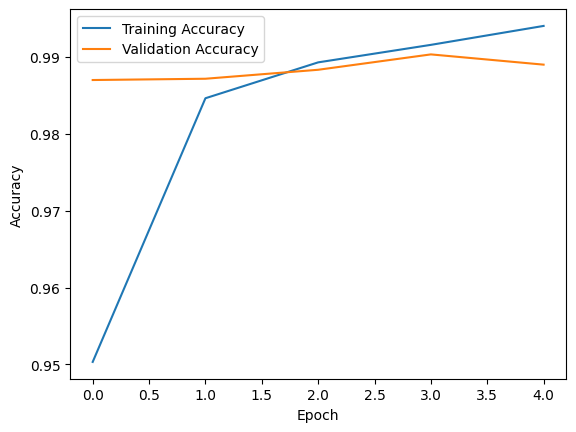

In [14]:
# 10. Plot training accuracy
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()